In [ ]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [ ]:
raw_data = load_iris()
dataset = raw_data.data

In [ ]:
d_scaler = MinMaxScaler()
dataset_scaled = d_scaler.fit_transform(dataset)

In [ ]:
mds_output = MDS(3,random_state=5)
data_3d = mds_output.fit_transform(dataset_scaled)

In [ ]:
mds_colors = ['purple','blue', 'yellow']



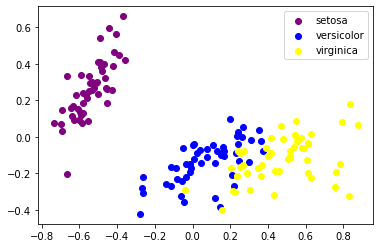

In [ ]:
for i in np.unique(raw_data.target):
  d_subset = data_3d[raw_data.target == i]

  x = [row[0] for row in d_subset]
  y = [row[1] for row in d_subset]
  plt.scatter(x,y,c=mds_colors[i],label=raw_data.target_names[i])
plt.legend()
plt.show()

In [ ]:
data_dummy_cities = {'A':[0,40,50,30,40],
          'B':[40,0,40,50,20],
          'C':[50,40,0,20,50],
          'D':[30,50,20,0,20],
          'E':[40,20,50,20,0],
          }

In [ ]:
cities_dataframe = pd.DataFrame(data_dummy_cities, index =['A','B','C','D','E'])

In [ ]:
cities_dataframe

,A,B,C,D,E
A,0,40,50,30,40
B,40,0,40,50,20
C,50,40,0,20,50
D,30,50,20,0,20
E,40,20,50,20,0


In [ ]:
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(cities_dataframe)

In [ ]:
MDS_stress = []


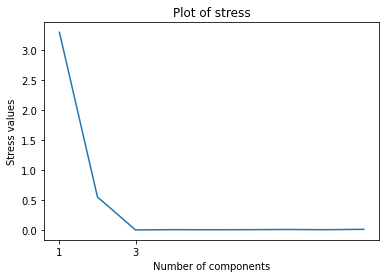

In [ ]:
for i in range(1, 10):
    mds = MDS(n_components=i)
    pts = mds.fit_transform(df_scaled)
    MDS_stress.append(mds.stress_)


plt.plot(range(1, 10), MDS_stress)
plt.xticks(range(1, 5, 2))
plt.title('Plot of stress')
plt.xlabel('Number of components')
plt.ylabel('Stress values')
plt.show()

In [ ]:
mds = MDS(n_components=3)
x = mds.fit_transform(df_scaled)


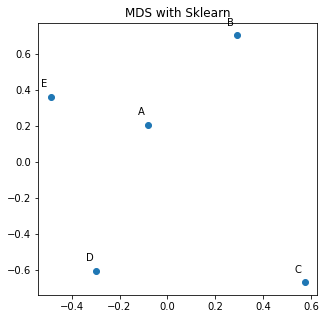

0.006562092893703815


In [ ]:
cities = ['A','B','C','D','E']

plt.figure(figsize=(5,5))
plt.scatter(x[:,0],x[:,1])
plt.title('MDS with Sklearn')
for label, x, y in zip(cities, x[:, 0], x[:, 1]):
    plt.annotate(
        label,
        xy = (x, y),
        xytext = (-10, 10),
        textcoords = 'offset points'
    )
plt.show()
print(mds.stress_)

# t-SNE

In [ ]:
from sklearn.manifold import TSNE
from keras.datasets import mnist
from sklearn.datasets import load_iris
from numpy import reshape
import seaborn as sns
import pandas as pd

In [ ]:
iris = load_iris()
iris_data = iris.data
iris_target = iris.target



In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
tsne = TSNE(n_components=2, verbose=3, random_state=5, perplexity=30)
fitted_data = tsne.fit_transform(iris_data)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.001s...
[t-SNE] Computed neighbors for 150 samples in 0.063s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 0.509910
[t-SNE] Computed conditional probabilities in 0.015s
[t-SNE] Iteration 50: error = 43.7347298, gradient norm = 0.2834327 (50 iterations in 0.042s)
[t-SNE] Iteration 100: error = 43.7584229, gradient norm = 0.3032500 (50 iterations in 0.054s)
[t-SNE] Iteration 150: error = 46.1576920, gradient norm = 0.3934466 (50 iterations in 0.044s)
[t-SNE] Iteration 200: error = 44.0951424, gradient norm = 0.3787453 (50 iterations in 0.040s)
[t-SNE] Iteration 250: error = 45.9728394, gradient norm = 0.2750182 (50 iterations in 0.041s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 45.972839
[t-SNE] Iteration 300: error = 0.1577595, gradient norm = 0.0071719 (50 iterations in 0.039s)
[t-SNE] Iteration 350: error = 0.1358411, gradient norm = 0.0038188 (

In [ ]:
tsne = TSNE(n_components=2, verbose=1, random_state=5, perplexity=100)
fitted_data = tsne.fit_transform(iris_data)

[t-SNE] Computing 149 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.000s...
[t-SNE] Computed neighbors for 150 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 2.238656
[t-SNE] KL divergence after 250 iterations with early exaggeration: 36.325634
[t-SNE] KL divergence after 850 iterations: 0.008607


[Text(0.5, 1.0, 'Iris data tSNE projection')]

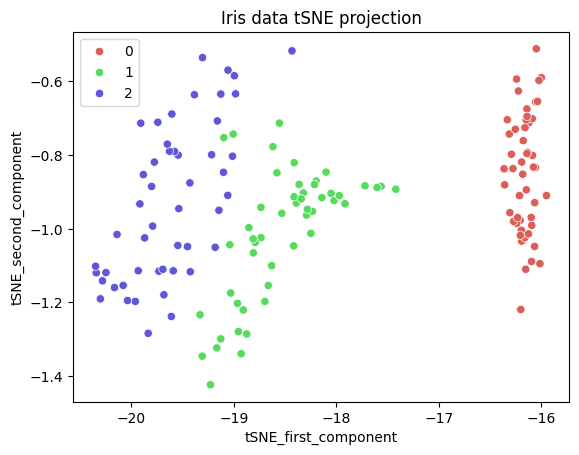

In [ ]:
iris_df = pd.DataFrame()
iris_df["iris_target"] = iris_target
iris_df["tSNE_first_component"] = fitted_data[:,0]
iris_df["tSNE_second_component"] = fitted_data[:,1]

sns.scatterplot(x="tSNE_first_component", y="tSNE_second_component", hue=iris_df.iris_target.tolist(),
                palette=sns.color_palette("hls", 3),
                data=iris_df).set(title="Iris data tSNE projection")

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.000s...
[t-SNE] Computed neighbors for 150 samples in 0.009s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 0.509910
[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.771782
[t-SNE] KL divergence after 1000 iterations: 1.601714


[Text(0.5, 1.0, 'Iris data T-SNE projection')]

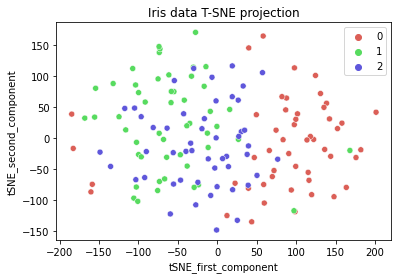

In [ ]:
iris = load_iris()
iris_data = iris.data
iris_target = iris.target

tsne = TSNE(n_components=3, verbose=1, random_state=5)
fitted_data = tsne.fit_transform(iris_data)
iris_df = pd.DataFrame()
iris_df["iris_target"] = iris_target
iris_df["tSNE_first_component"] = fitted_data[:,0]
iris_df["tSNE_second_component"] = fitted_data[:,1]

sns.scatterplot(x="tSNE_first_component", y="tSNE_second_component", hue=iris_df.iris_target.tolist(),
                palette=sns.color_palette("hls", 3),
                data=iris_df).set(title="Iris data T-SNE projection")

In [ ]:
(digit, digit_label), (_ , _) = mnist.load_data()


11490434/11490434 [==============================] - 1s 0us/step


In [ ]:
digit = reshape(digit, [digit.shape[0], digit.shape[1]*digit.shape[2]])


In [ ]:
tsne_MNIST = TSNE(n_components=2, verbose=1, random_state=5)


In [ ]:
fitted_data = tsne_MNIST.fit_transform(digit)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 60000 samples in 0.041s...
[t-SNE] Computed neighbors for 60000 samples in 297.362s...
[t-SNE] Computed conditional probabilities for sample 1000 / 60000
[t-SNE] Computed conditional probabilities for sample 2000 / 60000
[t-SNE] Computed conditional probabilities for sample 3000 / 60000
[t-SNE] Computed conditional probabilities for sample 4000 / 60000
[t-SNE] Computed conditional probabilities for sample 5000 / 60000
[t-SNE] Computed conditional probabilities for sample 6000 / 60000
[t-SNE] Computed conditional probabilities for sample 7000 / 60000
[t-SNE] Computed conditional probabilities for sample 8000 / 60000
[t-SNE] Computed conditional probabilities for sample 9000 / 60000
[t-SNE] Computed conditional probabilities for sample 10000 / 60000
[t-SNE] Computed conditional probabilities for sample 11000 / 60000
[t-SNE] Computed conditional probabilities for sample 12000 / 60000
[t-SNE] Computed conditional probabilities for s

In [ ]:
mnist_df = pd.DataFrame()
mnist_df["digit_label"] = digit_label
mnist_df["tSNE_first_component"] = fitted_data[:,0]
mnist_df["tSNE_second_component"] = fitted_data[:,1]



[Text(0.5, 1.0, 'MNIST data T-SNE projection')]

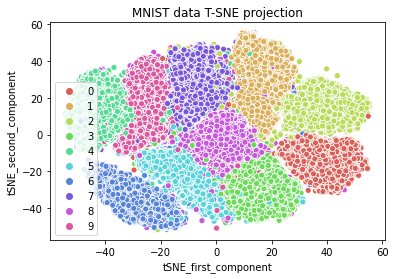

In [ ]:
sns.scatterplot(x="tSNE_first_component", y="tSNE_second_component", hue=mnist_df.digit_label.tolist(),
                palette=sns.color_palette("hls", 10),
                data=mnist_df).set(title="MNIST data T-SNE projection")